<a href="https://colab.research.google.com/github/KaueOPG/DCC127---Mineracao-de-Dados/blob/main/Trabalho3_Agrupamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 3 - Agrupamento

## Dayane Guimarães Gomes Godoy - 202265554C
## Kauê Oliveira Paraízo Garcia - 202265517B

## Imports

In [ ]:
!pip install numpy==1.26.4
!pip install scikit-learn-extra
!pip install kmodes
!pip install umap-learn

  Using cached scikit-learn-extra-0.3.0.tar.gz (818 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=1959513 sha256=0f812ef545bbaed2406b8cbb72d7a411f9f9d76031d6a3dfbeb15d418358acf2
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import  StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score
from sklearn_extra.cluster import KMedoids
from umap import UMAP



## Análise Inicial

In [ ]:
import pandas as pd

dataset_url = f"https://drive.google.com/uc?export=download&id=1XKDohANpfDXYp1mbNayswPpr5MZTtL1V"

df = pd.read_csv(dataset_url)

display(df.head())

In [ ]:
df.info()

In [ ]:
import matplotlib.pyplot as plt

# Contagem de valores nulos por coluna
valores_nulos = df.isnull().sum()

# Plotar gráfico
plt.figure(figsize=(10, 6))
ax = valores_nulos.plot(kind='bar')

plt.title('Quantidade de Valores Nulos por Coluna')
plt.xlabel('Colunas')
plt.ylabel('Quantidade de Valores Nulos')

for i, valor in enumerate(valores_nulos):
    ax.text(i, valor + 5, str(valor), ha='center', fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Não vamos usar a coluna Class, ela é apenas destinada para avaliar os métodos de clusterização
# df.drop(columns=['Class'], inplace=True)

In [ ]:
duplicadas = df.duplicated(subset=df.columns.difference(['Class'])).sum()
total_linhas = df.shape[0]
percentual_duplicadas = (duplicadas / total_linhas) * 100

print(f'Total de linhas: {total_linhas}')
print(f'Número de linhas duplicadas: {duplicadas}')
print(f'Percentual de duplicadas: {percentual_duplicadas:.2f}%')

valores = [duplicadas, total_linhas - duplicadas]
labels = ['Duplicadas', 'Únicas']

plt.figure(figsize=(7,7))
plt.pie( valores, labels=labels, autopct='%1.2f%%', startangle=90, textprops={'fontsize': 16})

plt.title('Proporção de Linhas Duplicadas no Dataset')
plt.show()

df.drop_duplicates(subset=df.columns.difference(['Class']),
    inplace=True)

In [ ]:
duplicate_songs = df[df.duplicated(
    subset=['Artist Name', 'Track Name'],
    keep=False
)]

qtd_dup_musicas = duplicate_songs.shape[0]
percentual_dup_musicas = (qtd_dup_musicas / df.shape[0]) * 100
qtd_unicos = df.shape[0] - qtd_dup_musicas

print(f"Número de registros duplicados por música/artista: {qtd_dup_musicas}")
print(f"Percentual: {percentual_dup_musicas:.2f}%\n")

# Gráfico
valores = [qtd_dup_musicas, qtd_unicos]
labels = ['Duplicados', 'Únicos']

plt.figure(figsize=(7,7))
wedges, texts, autotexts = plt.pie(valores, labels=labels, autopct='%1.2f%%', startangle=90, textprops={'fontsize': 16}  )

plt.title('Duplicidades por Música e Artista')
plt.figtext(
    0.5,
    0.02,
    'Algumas duplicatas restantes ocorreram devido a\n'
    'inconsistências na unidade da duração\n'
    '(minutos vs milissegundos).',
    ha='center',
    fontsize=10
)
plt.show()
display(duplicate_songs.sort_values(by=['Artist Name', 'Track Name']).head(20))

In [ ]:
import numpy as np

def converter_para_segundos(valor):

    if pd.isna(valor):
        return np.nan

    # minutos
    if valor < 30:
        return round(valor * 60, 3)

    # milissegundos
    elif valor > 10000:
        return round(valor / 1000, 3)

    else:
        return np.nan

# criar coluna padronizada por segundo e remover coluna antiga
df['duration_seconds'] = df['duration_in min/ms'].apply(converter_para_segundos)
df.drop(columns=['duration_in min/ms'], inplace=True)

# removendo duplicatas que antes não eram duplicatas pois a uniddae da duração era diferente
linhas_antes = df.shape[0]
cols = df.columns.difference(['Class'])

df = df.drop_duplicates(subset=cols)
linhas_depois = df.shape[0]

print(f"Linhas antes: {linhas_antes}")
print(f"Linhas depois: {linhas_depois}")
print(f"Linhas removidas: {linhas_antes - linhas_depois}")

In [ ]:
# Entendendo cada coluna para identificar possíveis colunas categoricas
print("Quantidade de valores distintos por coluna:")
for coluna in df.select_dtypes(include=['int64', 'float64']).columns:
    print(coluna, df[coluna].nunique())

In [ ]:
# Graficos das distribuição das colunas númericas
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
colunas_categoricas_codificadas = ['key', 'mode', 'time_signature']
for coluna in colunas_numericas:
    plt.figure(figsize=(8, 5))

    # Se for categórica codificada faz gráfico de barras
    if coluna in colunas_categoricas_codificadas or df[coluna].nunique() < 15:
        df[coluna].value_counts().sort_index().plot(kind='bar')

        plt.ylabel('Frequência')
        plt.xlabel(coluna)
        plt.title(f'Distribuição Categórica - {coluna}')
        plt.xticks(rotation=0)
    else:
        # Caso seja contínua faz histograma
        plt.hist(df[coluna].dropna(), bins=30)

        plt.ylabel('Frequência')
        plt.xlabel(coluna)
        plt.title(f'Distribuição Numérica - {coluna}')

    plt.tight_layout()
    plt.show()

    print("\n")

In [ ]:
# imputando valores ausentes nas colunas 'Popularity', 'key' e 'instrumentalness'
df['Popularity'] = df['Popularity'].fillna(df['Popularity'].median()) # imputa com a mediana
df['key'] = df['key'].fillna(df['key'].mode()[0]) # imputa com a moda
df['instrumentalness'] = df['instrumentalness'].fillna(df['instrumentalness'].median()) # imputa com a mediana
df.info()

In [ ]:
colunas_para_remover = ["Artist Name", "Track Name", "Cluster_PAM", "Class", "mode", "key", "time_signature"]
colunas_numéricas = [col for col in df.columns if col not in colunas_para_remover]

for coluna in colunas_numéricas:
    plt.figure(figsize=(12, 6))

    sns.violinplot(
        data=df,
        x='Class',
        y=coluna,
        palette='Set3',
        inner='box',
        cut=0
    )

    plt.title(f"Área Majoritária e Distribuição por Classe: {coluna}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Classes (Coluna Class)", fontsize=11)
    plt.ylabel(f"Valor Normalizado de {coluna}", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.4, axis='y')

    plt.tight_layout()
    plt.show()

## Correlação entre colunas númericas

In [ ]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r")
plt.title("Matriz de Correlação")
plt.show()

## Ajeitando escalas

In [ ]:
colunas_categoricas = ['mode', 'key', 'time_signature']
colunas_numericas = df.select_dtypes(include=['number']).drop(columns=colunas_categoricas)
skewness = colunas_numericas.apply(lambda x: x.skew()).sort_values(ascending=False)
positive_skewed_features = skewness[skewness > 2]
print(positive_skewed_features)

for feature in positive_skewed_features.index:
    df[feature] = np.log1p(df[feature])

In [ ]:
colunas_categoricas = ['mode', 'key', 'time_signature']
colunas_numericas = df.select_dtypes(include=['number']).drop(columns=colunas_categoricas)
skewness = colunas_numericas.apply(lambda x: x.skew()).sort_values(ascending=False)
negative_skewed_features = skewness[skewness < -2]
print(negative_skewed_features)

for feature in negative_skewed_features.index:
    df[feature] = np.log1p(df[feature].max() - df[feature])

## Tratamento de Outliers

In [ ]:
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

for coluna in colunas_numericas:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[coluna].dropna())

    plt.title(f'Boxplot - {coluna}')
    plt.ylabel(coluna)
    plt.tight_layout()
    plt.show()

    print("\n")

In [ ]:
df.describe()

In [ ]:
# Colunas categóricas codificadas (não tratar)
colunas_categoricas = ['mode', 'key', 'time_signature', 'Class']

# Selecionar apenas colunas numéricas não categóricas
colunas_continuas = [
    col for col in df.select_dtypes(include='number').columns
    if col not in colunas_categoricas
]

# Aplicando clipping por percentis [5%, 95%]
for coluna in colunas_continuas:

    limite_inferior = df[coluna].quantile(0.05)
    limite_superior = df[coluna].quantile(0.95)

    df[coluna] = df[coluna].clip(
        lower=limite_inferior,
        upper=limite_superior
    )

## Normalizando dados

In [ ]:
df.describe()

In [ ]:
# Normalizando todas as colunas númericas
# Fiquei na duvida se normaliza tudo mesmo parecendo q algumas colunas estão nomalizada de 0-1
numeric_cols = df.select_dtypes(include='number').columns.drop(['Class', 'mode', 'key', 'time_signature'])
scaler = StandardScaler()
df_normalizado = df.copy()
df_normalizado[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [ ]:
features = [
    'danceability',
    'energy',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'duration_seconds',
    'Popularity',
    'loudness',
    'tempo',
]


class_means = (df_normalizado.groupby('Class')[features].mean())
print(class_means)


plt.figure(figsize=(14,7))

for classe in class_means.index:
    plt.plot(
        features,
        class_means.loc[classe],
        marker='o',
        linewidth=2,
        label=f'Classe {classe}'
    )

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Média")

plt.title("Caracterização das Classes pelas Features")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
df_normalizado.describe()

## Clusterização

### PAM

In [ ]:
colunas_para_remover = ["Artist Name", "Track Name", "Class", "mode", "key", "time_signature"]
colunas_cluster = [col for col in df_normalizado.columns if col not in colunas_para_remover]
X = df_normalizado[colunas_cluster]

scores_silhueta = []
valores_k = range(2, 15)

for k in valores_k:
    kmedoids = KMedoids(n_clusters=k, metric='euclidean', random_state=42)
    labels = kmedoids.fit_predict(X)

    score = silhouette_score(X, labels, metric='euclidean')
    scores_silhueta.append(score)

plt.figure(figsize=(8, 4))
plt.plot(valores_k, scores_silhueta, marker='s', linestyle='-', color='g')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Coeficiente de Silhueta Médio')
plt.title('Validação pelo Coeficiente de Silhueta')
plt.grid(True)
plt.show()

In [ ]:
k_escolhido = 7

pam_final = KMedoids(n_clusters=k_escolhido, metric='euclidean', random_state=42)
df_normalizado['Cluster_PAM'] = pam_final.fit_predict(X)
coluna_pam = df_normalizado['Cluster_PAM']

print("\n--- Quantidade de músicas por cluster ---")
contagem_clusters = df_normalizado['Cluster_PAM'].value_counts().sort_index()
print(contagem_clusters)


--- Quantidade de músicas por cluster ---
Cluster_PAM
0    1379
1    1193
2    1196
3    1034
4    1334
5    1911
6    1389
Name: count, dtype: int64


--- Médias das Características por Cluster PAM ---
             danceability    energy  speechiness  acousticness  \
Cluster_PAM                                                      
0               -0.443126 -1.565707    -0.507823      1.603146   
1               -0.092803  0.295375    -0.415322     -0.510821   
2               -0.023301 -0.037891    -0.390086     -0.563347   
3                0.287388  0.348007    -0.436932     -0.095719   
4                0.226495 -0.187056    -0.407245      0.512194   
5               -0.781604  0.992791     0.205304     -0.706536   
6                1.183581 -0.111941     1.630689     -0.116392   

             instrumentalness  liveness   valence  duration_seconds      mode  \
Cluster_PAM                                                                     
0                    0.751862 -0.370290 -0.901254          0.228927  0.671501   
1                    0.019529 -0.058556 -0.294528          0.384062  0.651299   
2                   -0.123147 

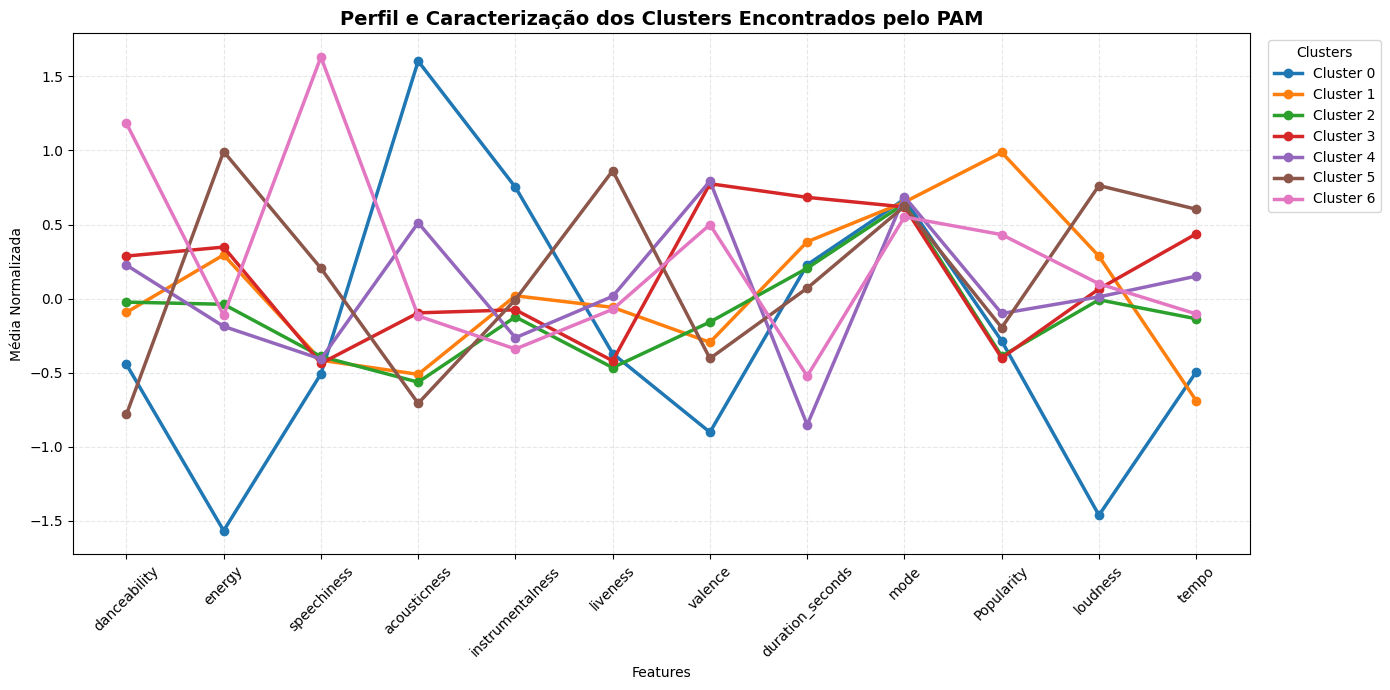

In [ ]:
features = [
    'danceability',
    'energy',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'duration_seconds',
    'mode',
    'Popularity',
    'loudness',
    'tempo',
]

cluster_means = (
    df_normalizado
    .groupby('Cluster_PAM')[features]
    .mean()
)

print("--- Médias das Características por Cluster PAM ---")
print(cluster_means)

plt.figure(figsize=(14, 7))

for cluster in cluster_means.index:
    plt.plot(
        features,
        cluster_means.loc[cluster],
        marker='o',
        linewidth=2.5,
        label=f'Cluster {cluster}'
    )

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Média Normalizada")

plt.title("Perfil e Caracterização dos Clusters Encontrados pelo PAM", fontsize=14, fontweight='bold')

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Clusters')
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

/tmp/ipykernel_13767/2573288926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


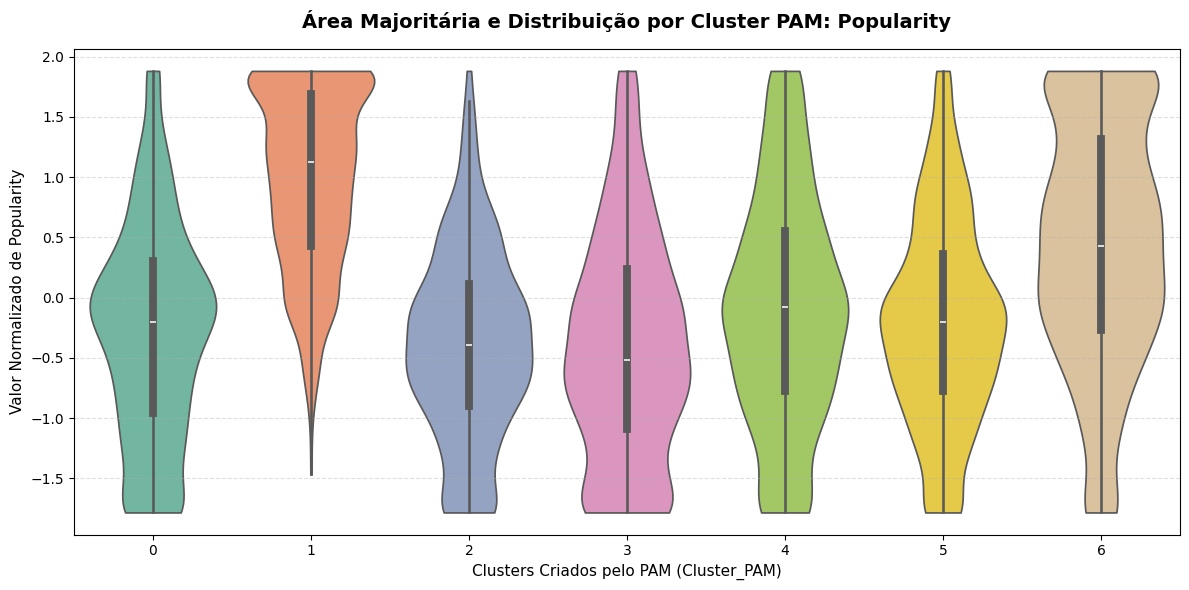

/tmp/ipykernel_13767/2573288926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


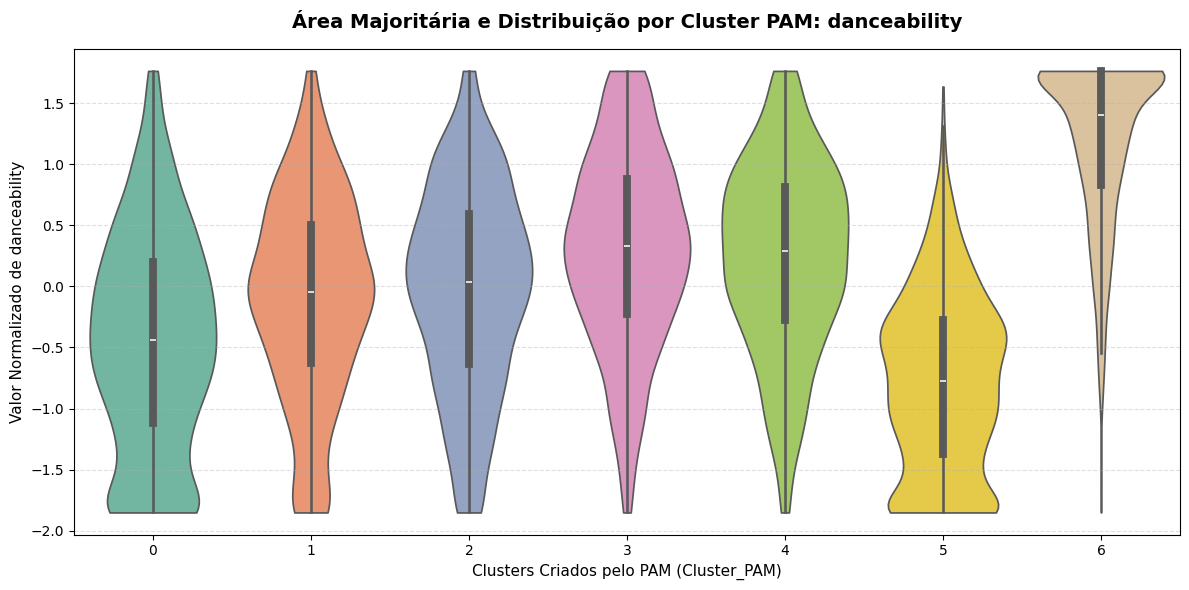

/tmp/ipykernel_13767/2573288926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


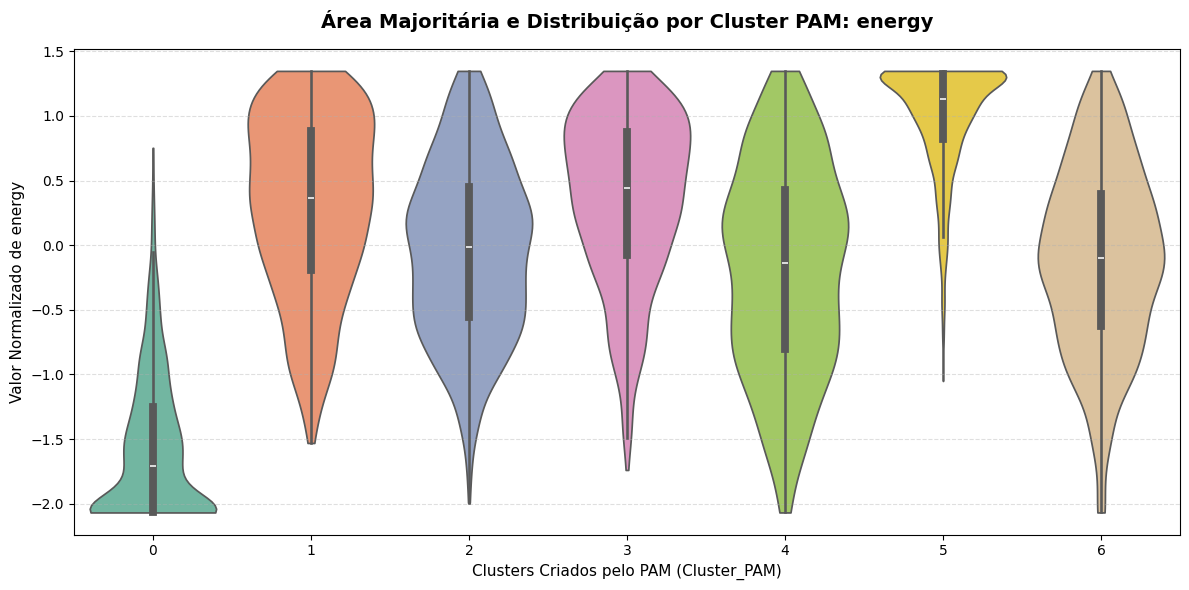

/tmp/ipykernel_13767/2573288926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


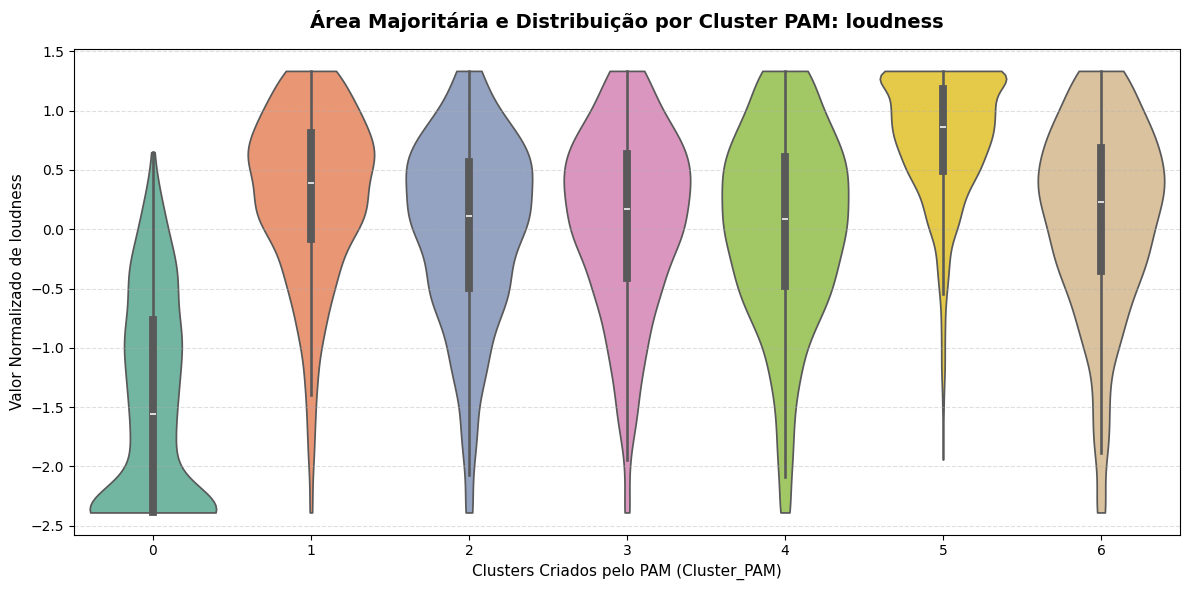

/tmp/ipykernel_13767/2573288926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


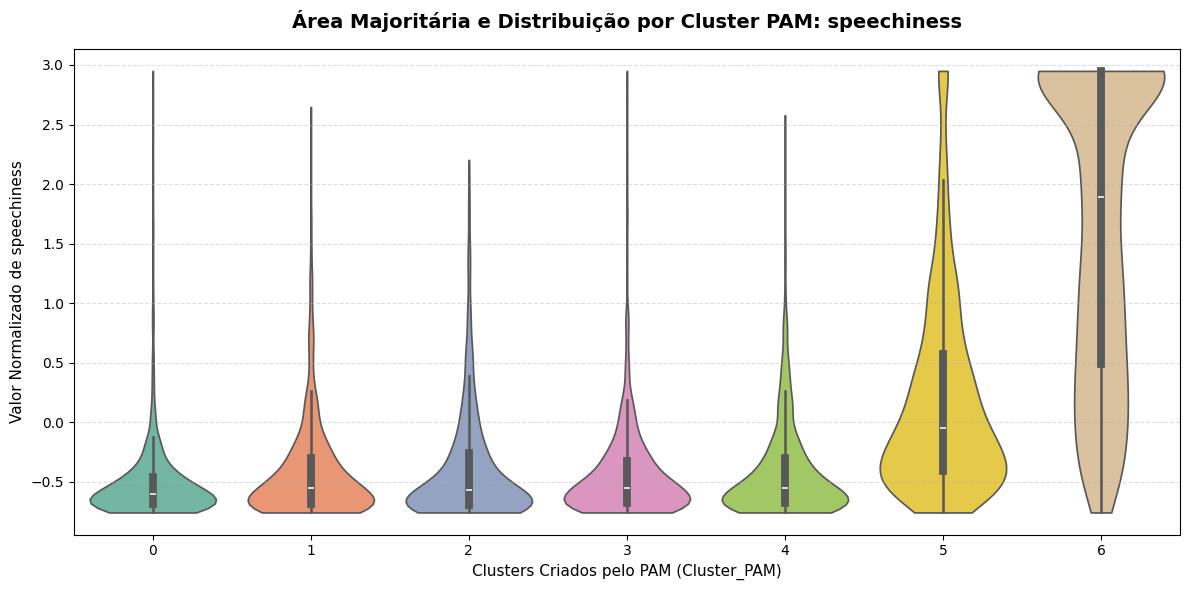

/tmp/ipykernel_13767/2573288926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


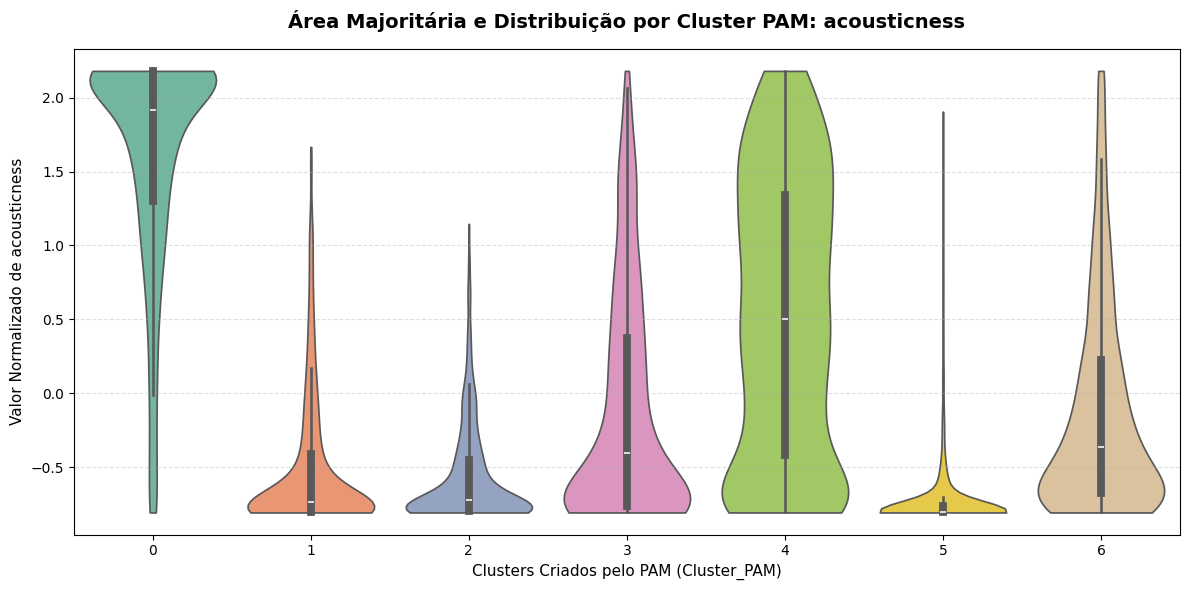

/tmp/ipykernel_13767/2573288926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


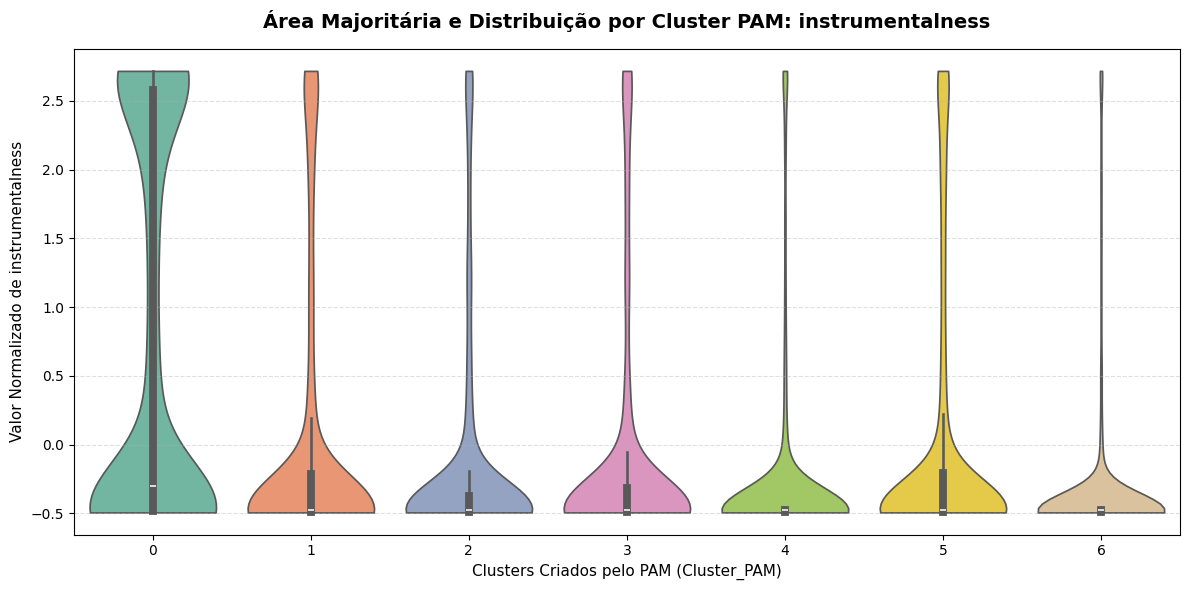

/tmp/ipykernel_13767/2573288926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


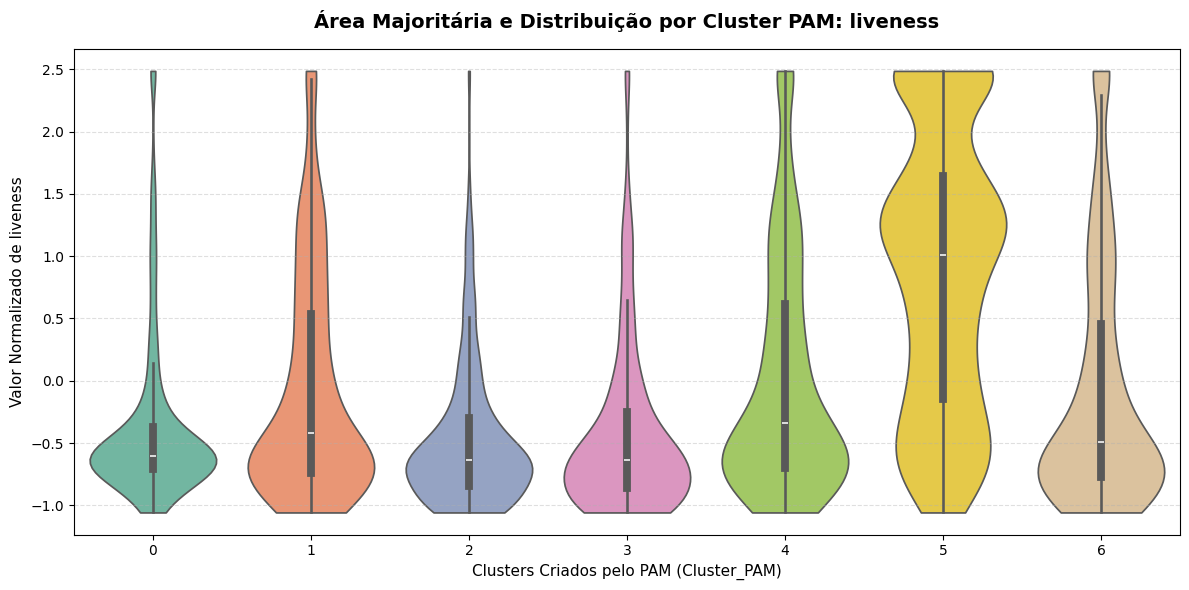

/tmp/ipykernel_13767/2573288926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


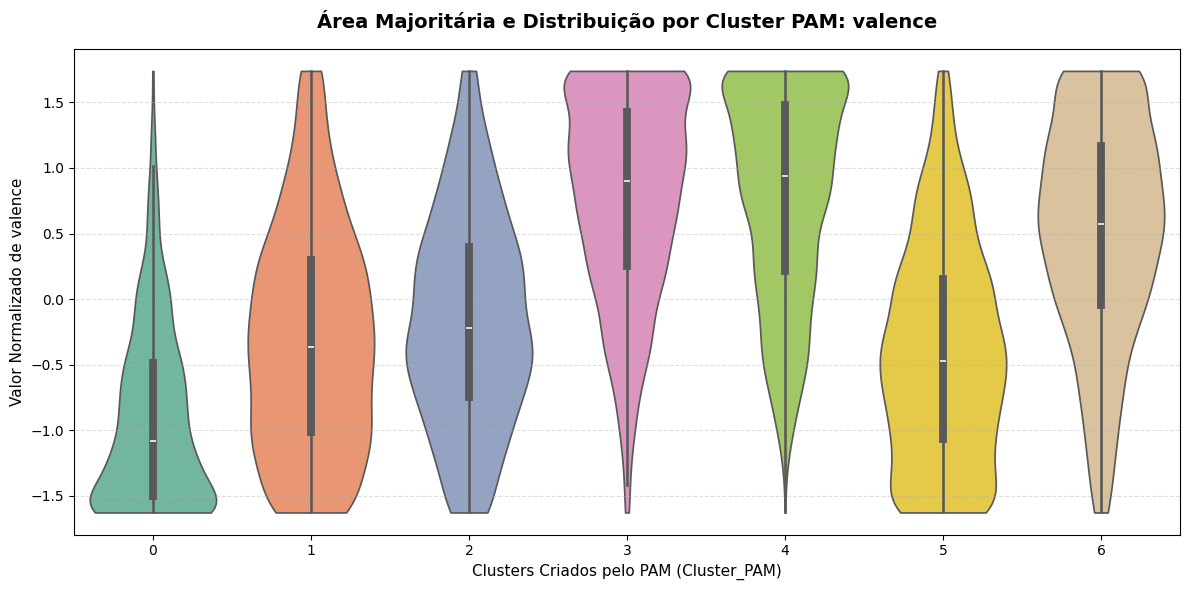

/tmp/ipykernel_13767/2573288926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


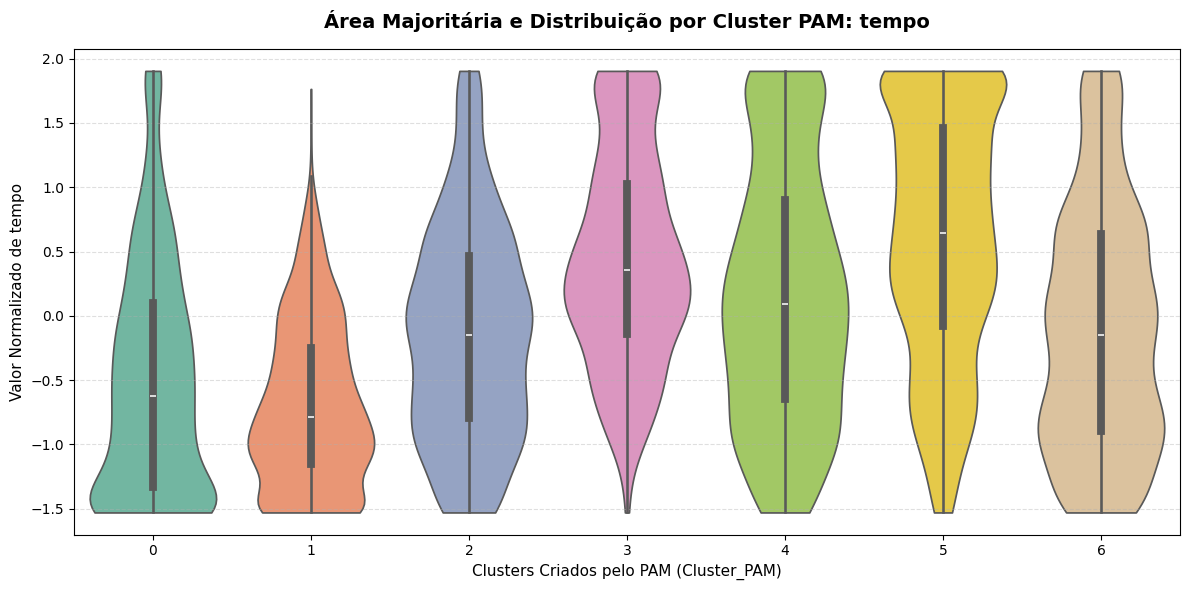

/tmp/ipykernel_13767/2573288926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


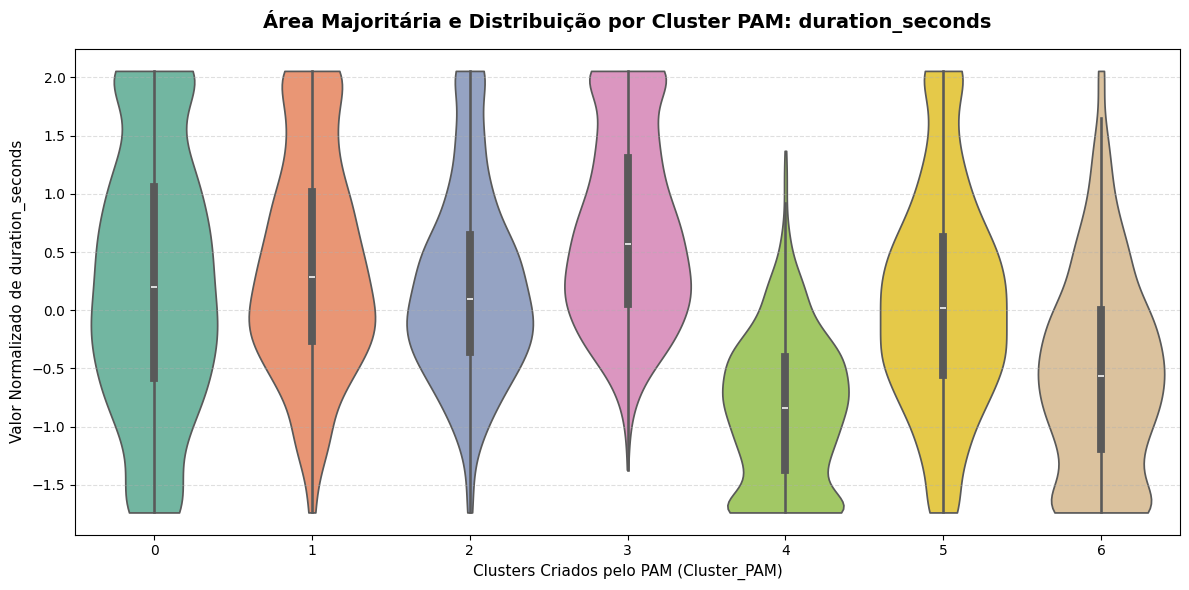

In [ ]:
colunas_para_remover = ["Artist Name", "Track Name", "Cluster_PAM", "Class", "mode", "key", "time_signature"]
colunas_numéricas = [col for col in df_normalizado.columns if col not in colunas_para_remover]

for coluna in colunas_numéricas:
    plt.figure(figsize=(12, 6))

    sns.violinplot(
        data=df_normalizado,
        x='Cluster_PAM',
        y=coluna,
        palette='Set2',
        inner='box',
        cut=0
    )

    plt.title(f"Área Majoritária e Distribuição por Cluster PAM: {coluna}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Clusters Criados pelo PAM (Cluster_PAM)", fontsize=11)
    plt.ylabel(f"Valor Normalizado de {coluna}", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.4, axis='y')

    plt.tight_layout()
    plt.show()

### KPrototypes

K = 3 | Silhouette = 0.1411
K = 4 | Silhouette = 0.1433
K = 5 | Silhouette = 0.1411
K = 6 | Silhouette = 0.1439
K = 7 | Silhouette = 0.1387
K = 8 | Silhouette = 0.1322
K = 9 | Silhouette = 0.1252
K = 10 | Silhouette = 0.1185
K = 11 | Silhouette = 0.1160
K = 12 | Silhouette = 0.1148
K = 13 | Silhouette = 0.1151
K = 14 | Silhouette = 0.1100

Melhor K: 6


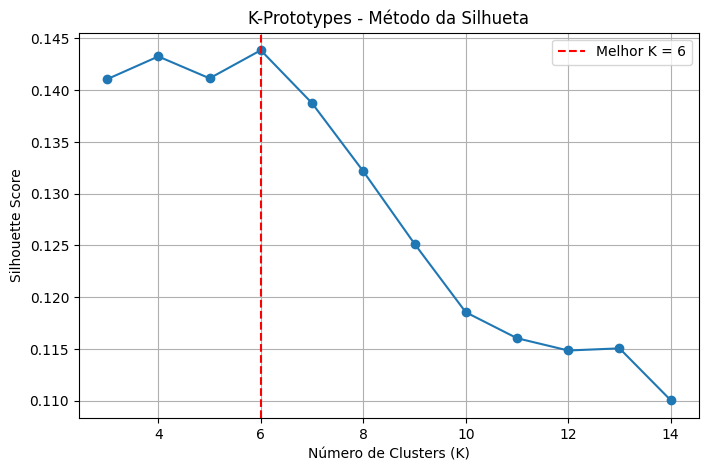

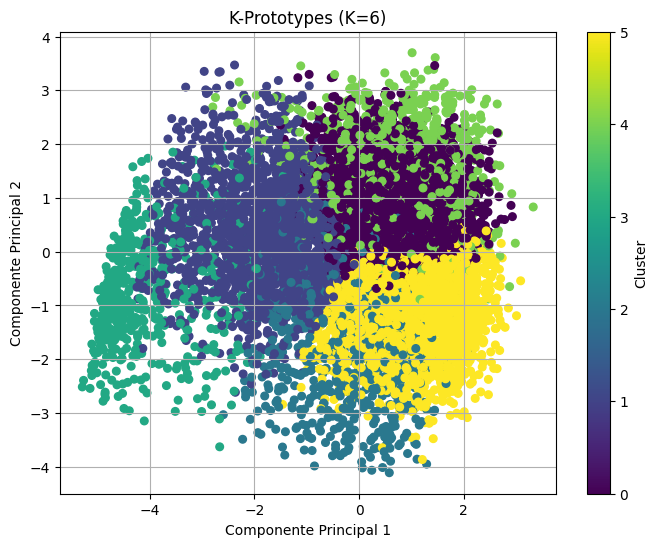

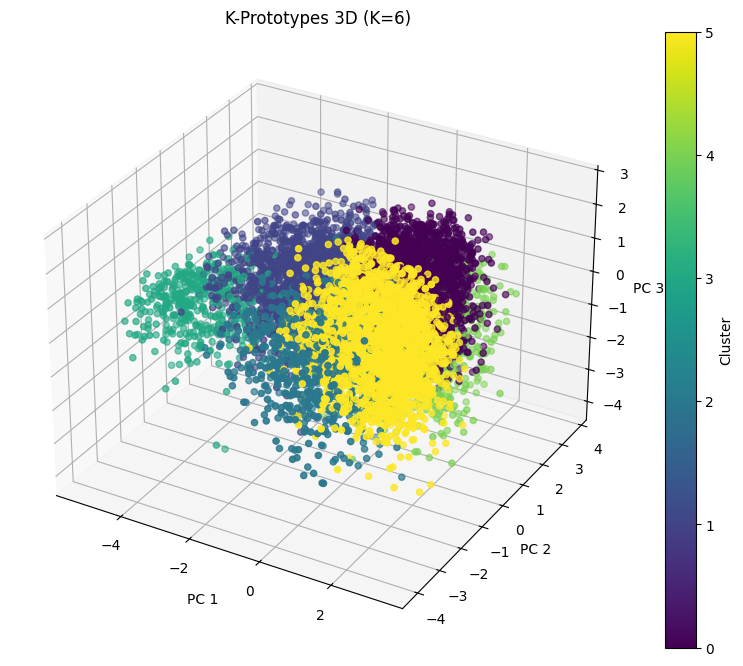

In [ ]:
from kmodes.kprototypes import KPrototypes
colunas_numericas = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'Popularity',
    'duration_seconds'
]

colunas_categoricas = [
    'mode',
    'key'
]

df_cluster = df_normalizado[colunas_numericas + colunas_categoricas].copy()
for col in colunas_categoricas:
    df_cluster[col] = df_cluster[col].astype(str)

X = df_cluster.to_numpy()

# índices das categóricas
categorical_idx = [df_cluster.columns.get_loc(col) for col in colunas_categoricas]

# Testando vários K
silhuetas = []

for k in range(3, 15):
    kproto = KPrototypes(n_clusters=k,init='Cao', random_state=42, n_init=5)
    labels = kproto.fit_predict(X, categorical=categorical_idx)

    # silhouette usa apenas parte numérica
    score = silhouette_score( df_normalizado[colunas_numericas], labels)
    silhuetas.append(score)
    print(f"K = {k} | Silhouette = {score:.4f}")

# Melhor K
melhor_k = range(3, 15)[silhuetas.index(max(silhuetas))]
print("\nMelhor K:", melhor_k)

# Plot silhouette
plt.figure(figsize=(8,5))
plt.plot(range(3, 15), silhuetas, marker='o')

plt.axvline(melhor_k,color='red', linestyle='--', label=f"Melhor K = {melhor_k}")

plt.xlabel("Número de Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Prototypes - Método da Silhueta")
plt.legend()
plt.grid()

plt.show()
print('\n')
# Rodando modelo final
kproto_final = KPrototypes(n_clusters=melhor_k, init='Cao', random_state=42, n_init=5)
labels_final = kproto_final.fit_predict(X, categorical=categorical_idx)
df_normalizado['Cluster_Kprotoype'] = labels_final

# vizualização
pca = PCA(n_components=2)

X_pca_vis = pca.fit_transform( df_normalizado[colunas_numericas])
plt.figure(figsize=(8,6))
plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=labels_final, cmap='viridis', s=30)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title(f"K-Prototypes (K={melhor_k})")
plt.colorbar(label="Cluster")
plt.grid()

plt.show()

#3d
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(df_normalizado[colunas_numericas])

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter( X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=labels_final, cmap='viridis', s=20)

ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
ax.set_title(f"K-Prototypes 3D (K={melhor_k})")

fig.colorbar(scatter, label="Cluster")
print('\n')
plt.show()


## Avaliação

### Avaliando a clusterização feita com K-prototypes

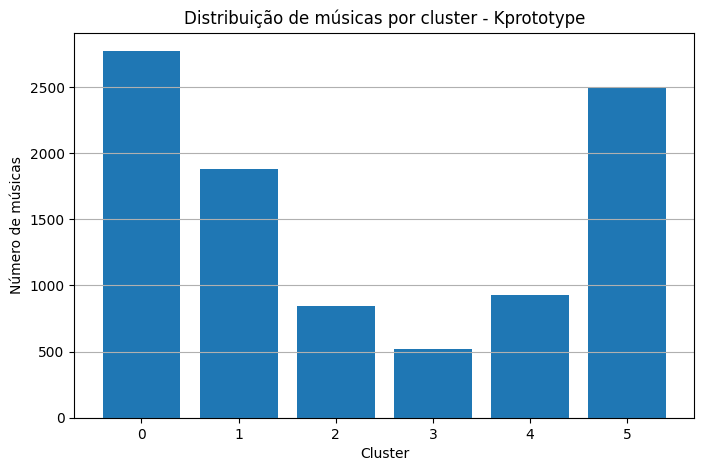

In [ ]:
import matplotlib.pyplot as plt

# contagem por cluster
contagem_clusters = df_normalizado['Cluster_Kprotoype'].value_counts().sort_index()
plt.figure(figsize=(8,5))

plt.bar(contagem_clusters.index.astype(str), contagem_clusters.values)

plt.xlabel("Cluster")
plt.ylabel("Número de músicas")
plt.title("Distribuição de músicas por cluster - Kprototype")
plt.grid(axis='y')

plt.show()

Classe Original distribuída nos Clusters - Kprototypes
Cluster_Kprotoype       0       1       2       3       4       5
Class                                                            
0                   9.67%  70.69%   4.83%   4.53%    0.0%  10.27%
1                  37.33%  14.46%  11.98%    4.2%   5.75%  26.28%
2                  32.88%   37.1%   3.77%   4.37%   3.47%   18.4%
3                  10.76%  66.82%   3.59%   8.52%   5.38%   4.93%
4                  55.25%  32.42%   0.46%    0.0%   1.83%  10.05%
5                  20.47%   6.54%   1.48%   0.25%  67.69%   3.58%
6                  32.95%  15.05%  17.43%   7.45%   7.14%  19.97%
7                   0.62%  11.11%   0.93%  87.04%   0.31%    0.0%
8                   8.37%   3.09%  25.02%    1.4%    0.6%  61.52%
9                  47.17%  28.04%   1.47%   0.46%  10.61%  12.24%
10                 32.25%  15.61%   7.77%    1.1%   2.44%  40.82%




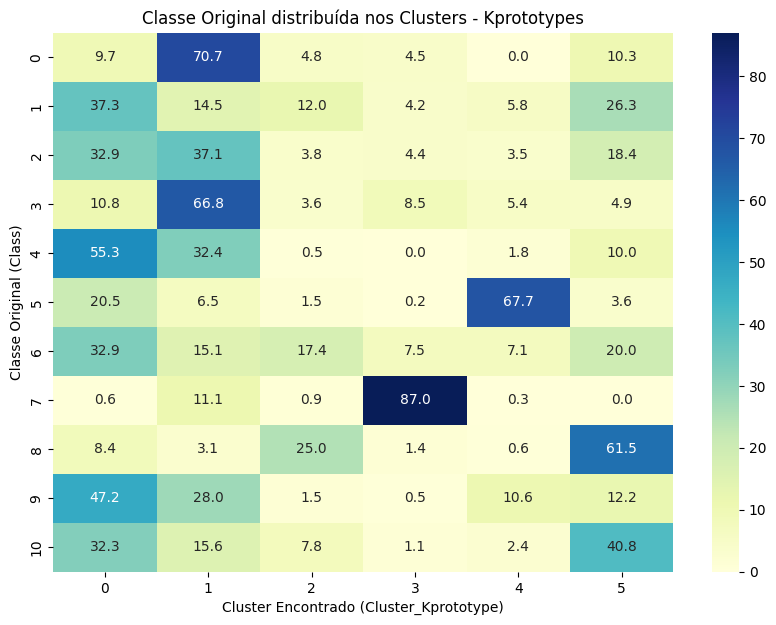

In [ ]:
matriz_base = pd.crosstab(df_normalizado['Class'], df_normalizado['Cluster_Kprotoype'])
porcentagem_classe = matriz_base.div(matriz_base.sum(axis=1), axis=0) * 100

print("Classe Original distribuída nos Clusters - Kprototypes")
print(porcentagem_classe.round(2).astype(str) + '%')
print("\n" + "="*60 + "\n")

plt.figure(figsize=(10, 7))
sns.heatmap(porcentagem_classe, annot=True, fmt=".1f", cmap="YlGnBu", cbar=True)
plt.title("Classe Original distribuída nos Clusters - Kprototypes")
plt.ylabel("Classe Original (Class)")
plt.xlabel("Cluster Encontrado (Cluster_Kprototype)")
plt.show()

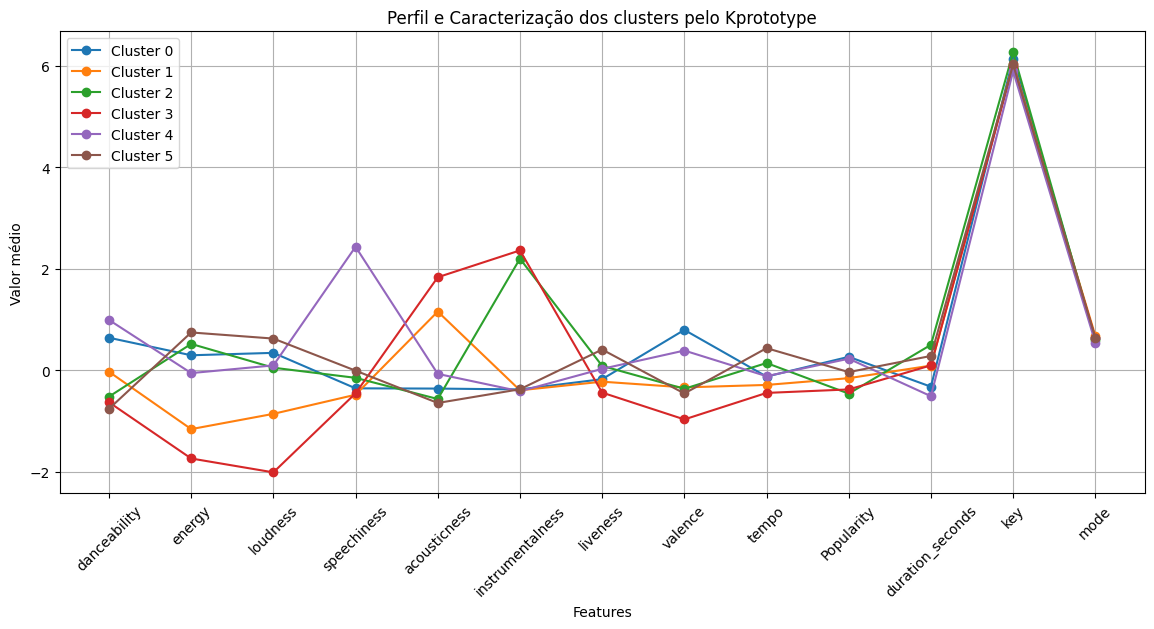

In [ ]:
colunas_kproto = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'Popularity',
    'duration_seconds',
    'key',
    'mode'
]

# média por cluster
media_clusters = df_normalizado.groupby('Cluster_Kprotoype')[colunas_kproto].mean()

plt.figure(figsize=(14,6))

for cluster in media_clusters.index:
    plt.plot(colunas_kproto, media_clusters.loc[cluster], marker='o', label=f'Cluster {cluster}')

plt.title("Perfil e Caracterização dos clusters pelo Kprototype")
plt.xlabel("Features")
plt.ylabel("Valor médio")
plt.xticks(rotation=45)
plt.grid()
plt.legend()

plt.show()

In [ ]:
display(df_normalizado[['Track Name', 'Artist Name', 'Class', 'Cluster_Kprotoype']].head(15))

,Track Name,Artist Name,Class,Cluster_Kprotoype
0,Decay,Moskva-Kassiopeya,6,2
1,Stereotypes,Black Violin,5,1
2,Let There Be Rock,AC/DC,10,2
3,Fear,Bumpin Uglies,10,0
4,Fire In The Blood - Live Masterlink Session,Jade Like The Stone,10,1
5,champagne problems,Taylor Swift,9,1
6,My Way - 1993 Remastered Version,Sid Vicious,1,2
7,Monster,The One Hundred,8,5
8,TWELVE,Shygirl,6,4
9,Mrs. David,Seaway,10,5


In [ ]:
y_true = df_normalizado['Class']
y_pred = labels_final

df_avaliacao = pd.DataFrame([{
    "Modelo": "K-Prototypes",
    "ARI": adjusted_rand_score(y_true, y_pred),
    "NMI": normalized_mutual_info_score(y_true, y_pred)
}])

df_avaliacao

,Modelo,ARI,NMI
0,K-Prototypes,0.100508,0.186353


### Avaliando a clusterização feita com PAM

Classe Original distribuída nos Clusters - PAM
Cluster_PAM       0       1       2       3       4       5       6
Class                                                              
0            49.55%   1.81%  10.57%  12.69%  21.15%   3.32%   0.91%
1            10.26%  12.13%  16.95%  12.91%  18.04%  18.82%  10.89%
2            17.95%   1.51%  15.38%  22.02%  27.45%  10.71%   4.98%
3            31.84%   6.28%   2.24%  26.46%  26.01%   1.79%   5.38%
4            10.05%  21.46%   9.59%   9.13%  38.81%   4.57%   6.39%
5             1.48%    5.8%   4.32%   3.33%   5.55%   3.08%  76.45%
6            14.98%  12.98%  14.44%   12.9%  16.36%  14.98%  13.36%
7            94.75%    0.0%    0.0%   2.16%   2.16%   0.62%   0.31%
8             4.39%  16.75%  10.77%   5.78%    0.9%  60.62%    0.8%
9            11.46%  14.02%  13.25%   9.91%  18.67%   6.89%  25.79%
10             8.8%  18.01%  16.07%  11.27%  11.73%  29.51%   4.61%




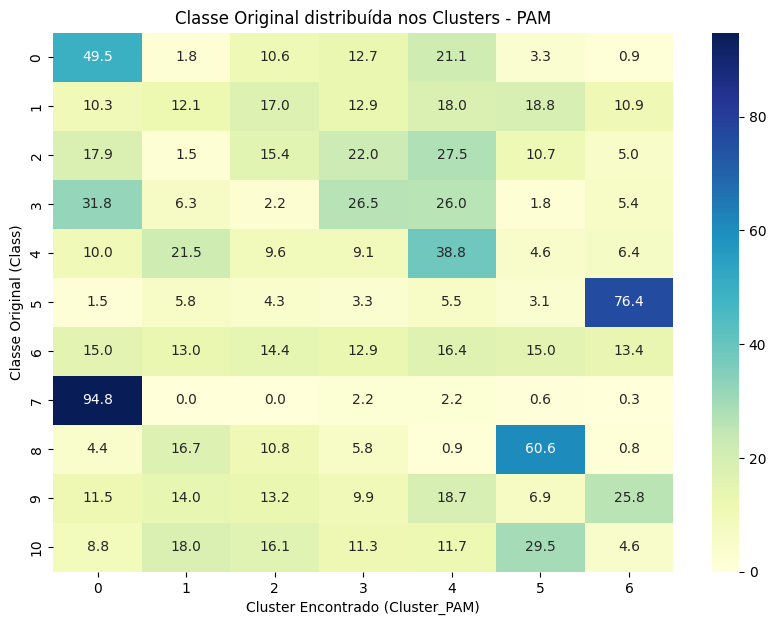

In [ ]:
df_normalizado['Cluster_PAM'] = coluna_pam

matriz_base = pd.crosstab(df_normalizado['Class'], df_normalizado['Cluster_PAM'])

porcentagem_classe = matriz_base.div(matriz_base.sum(axis=1), axis=0) * 100

print("Classe Original distribuída nos Clusters - PAM")
print(porcentagem_classe.round(2).astype(str) + '%')
print("\n" + "="*60 + "\n")

plt.figure(figsize=(10, 7))
sns.heatmap(porcentagem_classe, annot=True, fmt=".1f", cmap="YlGnBu", cbar=True)
plt.title("Classe Original distribuída nos Clusters - PAM")
plt.ylabel("Classe Original (Class)")
plt.xlabel("Cluster Encontrado (Cluster_PAM)")
plt.show()

In [ ]:
classes_reais = df_normalizado['Class']
labels_pam = df_normalizado['Cluster_PAM']

ari_pam = adjusted_rand_score(classes_reais, labels_pam)
nmi_pam = normalized_mutual_info_score(classes_reais, labels_pam)

dados_tabela = {
    "METODO": ["PAM (K-Medoids)"],
    "NUMERO DE CLUSTERS": [len(labels_pam.unique())],
    "ARI": [round(ari_pam, 6)],
    "NMI": [round(nmi_pam, 6)]
}

df_avaliacao_pam = pd.DataFrame(dados_tabela)

print("\nTabela.1: Avaliação dos clusters gerados com as classes reais")
print("="*60)
display(df_avaliacao_pam)
print("="*60)


Tabela.1: Avaliação dos clusters gerados com as classes reais


,METODO,NUMERO DE CLUSTERS,ARI,NMI
0,PAM (K-Medoids),7,0.083595,0.148231


In [ ]:
display(df_normalizado[['Track Name', 'Artist Name', 'Class', 'Cluster_PAM']].head(15))

,Track Name,Artist Name,Class,Cluster_PAM
0,Decay,Moskva-Kassiopeya,6,0
1,Stereotypes,Black Violin,5,4
2,Let There Be Rock,AC/DC,10,2
3,Fear,Bumpin Uglies,10,2
4,Fire In The Blood - Live Masterlink Session,Jade Like The Stone,10,2
5,champagne problems,Taylor Swift,9,0
6,My Way - 1993 Remastered Version,Sid Vicious,1,5
7,Monster,The One Hundred,8,5
8,TWELVE,Shygirl,6,6
9,Mrs. David,Seaway,10,5


### Comparando métodos de clusterização

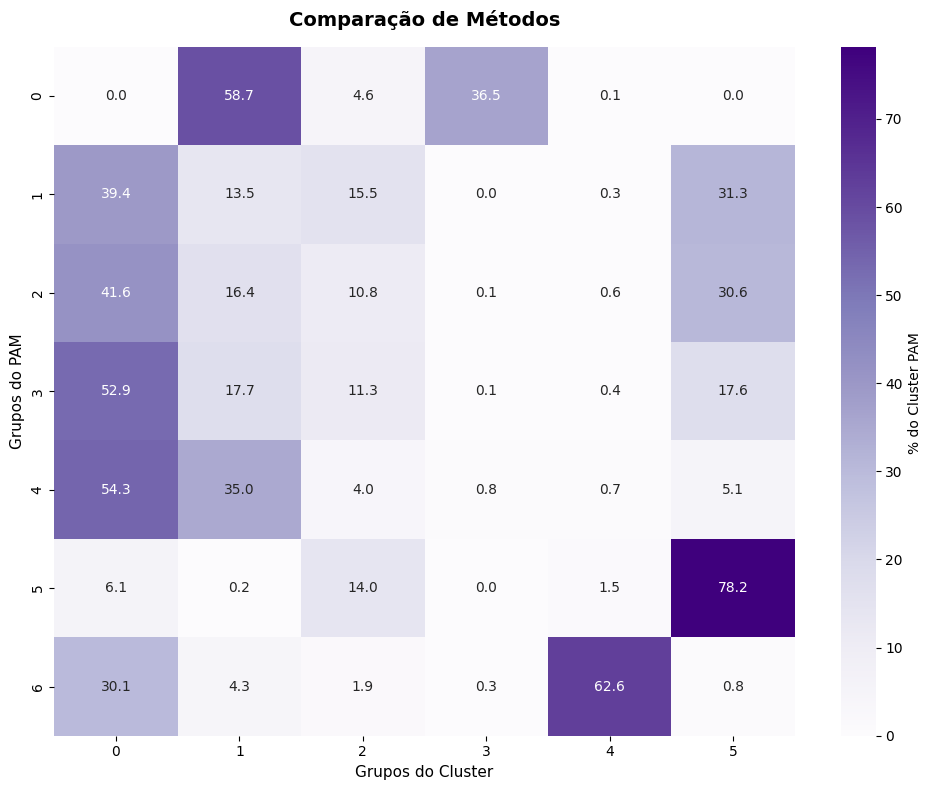

In [ ]:
matriz_acordo_linha = pd.crosstab(
    df_normalizado['Cluster_PAM'],
    df_normalizado['Cluster_Kprotoype'],
    normalize='index'
) * 100

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_acordo_linha,
    annot=True,
    fmt=".1f",
    cmap="Purples",
    cbar_kws={'label': '% do Cluster PAM '}
)

plt.title("Comparação de Métodos", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Grupos do PAM", fontsize=11)
plt.xlabel("Grupos do Cluster", fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
display(df_normalizado[['Track Name', 'Artist Name', 'Class', 'Cluster_PAM', 'Cluster_Kprotoype']].head(15))

,Track Name,Artist Name,Class,Cluster_PAM,Cluster_Kprotoype
0,Decay,Moskva-Kassiopeya,6,0,2
1,Stereotypes,Black Violin,5,4,1
2,Let There Be Rock,AC/DC,10,2,2
3,Fear,Bumpin Uglies,10,2,0
4,Fire In The Blood - Live Masterlink Session,Jade Like The Stone,10,2,1
5,champagne problems,Taylor Swift,9,0,1
6,My Way - 1993 Remastered Version,Sid Vicious,1,5,2
7,Monster,The One Hundred,8,5,5
8,TWELVE,Shygirl,6,6,4
9,Mrs. David,Seaway,10,5,5
